# Basil leaf quality: complete training notebook
This notebook contains all the Python implementation. No project helper scripts or web app are required.

**Dataset status: partial download.** IEEE downloads were rate-limited. The supplied ZIP has no Pune folder and is missing some Nagpur and Unhealthy files. This notebook runs a clearly labelled partial-dataset experiment using only explicitly labelled folders. Actual training status and measured results are shown in the executed cells below. No missing images are invented or substituted.

The seven stages are data collection, preprocessing, feature engineering, model selection, training, evaluation, and saving/using the model. The final stage runs predictions inside the notebook. An optional local Basil Lab website also loads the saved model for photo uploads and the training report.

## Before starting
Open this notebook in Jupyter or VS Code and select the existing `.venv` Python environment. A virtual environment isolates the project packages from other projects; the existing one is retained so you do not need to reinstall them. From this folder you can launch Jupyter with `.\.venv\Scripts\python.exe -m jupyter lab Basil_Leaf_ML_Workflow.ipynb`.

If using a different Python environment, uncomment and run the installation line below once, then restart the kernel. Python 3.11 or newer is recommended. Run the notebook from top to bottom. Outputs are created only when data is ready.

In [1]:
# Optional installation in the notebook's selected Python environment:
# %pip install "numpy>=2.2,<3" "pandas>=2.2,<4" "pillow>=11,<13" "scipy>=1.13,<2" "scikit-learn>=1.6,<2" "scikit-image>=0.25,<0.27" "matplotlib>=3.9,<4" "joblib>=1.4,<2"
# Optional deep feature comparison only:
# %pip install torch torchvision

In [2]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()  # Folder containing this notebook; change if necessary.
DATA_DIR = ROOT / "data" / "raw"
OUTPUT_DIR = ROOT / "outputs"
USE_TRANSFER = False  # True adds frozen ImageNet MobileNet features; requires torch/torchvision and a weight download.
ALLOW_PARTIAL_DATA = True  # Download was rate-limited; report coverage and never claim a complete-dataset result.
DATA_READY = False
SEED = 42
FEATURE_VERSION = "rgb-hsv-lbp-hog-v1"
SOURCE_URL = "https://ieee-dataport.org/open-access/leaves-indias-most-famous-basil-plant-leaves-quality-dataset"
DOI = "10.21227/a4f6-4413"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}
FOLDERS = {
    "Amravati_Region_Basil_Plant_Healthy": ("Healthy", 31),
    "Nagpur_Region_Basil_Plant_Healthy": ("Healthy", 473),
    "Pune_Region_Basil_Plant_Healthy": ("Healthy", 146),
    "Basil_Plant_Unhealthy": ("Unhealthy", 481),
}
print("Python:", sys.executable)
print("Download destination:", DATA_DIR)
print("Training results will be saved in:", OUTPUT_DIR)

Python: D:\SLIIT\projectr\Dataset_Train\.venv\Scripts\python.exe
Download destination: D:\SLIIT\projectr\Dataset_Train\data\raw
Training results will be saved in: D:\SLIIT\projectr\Dataset_Train\outputs


## 1. Data collection
Download from the [IEEE DataPort dataset page](https://ieee-dataport.org/open-access/leaves-indias-most-famous-basil-plant-leaves-quality-dataset), DOI **10.21227/a4f6-4413**. Retain the original images and source folder names.

| Download this folder | Label used | Listed files |
|---|---|---:|
| Amravati_Region_Basil_Plant_Healthy | Healthy | 31 |
| Nagpur_Region_Basil_Plant_Healthy | Healthy | 473 |
| Pune_Region_Basil_Plant_Healthy | Healthy | 146 |
| Basil_Plant_Unhealthy | Unhealthy | 481 |

This is **650 Healthy + 481 Unhealthy = 1,131 image entries** before auditing. Do not also download `Amravati`, `Nagpur`, `Pune`, or `Bad` for this experiment: the explicit label folders are sufficient, and the other folders may repeat images. Do not download `futures-3.3.0.tar.gz`; it is not image data. The list counts are a completeness check, not the number of independent examples.

Place the four folders directly in `data/raw/`, next to the notebook as follows (extract archives first):
```text
Dataset_Train/
  Basil_Leaf_ML_Workflow.ipynb
  data/raw/
    Amravati_Region_Basil_Plant_Healthy/  (images here)
    Nagpur_Region_Basil_Plant_Healthy/    (images here)
    Pune_Region_Basil_Plant_Healthy/      (images here)
    Basil_Plant_Unhealthy/               (images here)
```
Do not insert another `Basil` wrapper directory. The existing `Good.jpeg` is preserved. Folder names supply the published health labels; regional names are **not** separate quality classes. These labels do not identify specific diseases.

The supplied ZIP is incomplete. `ALLOW_PARTIAL_DATA=True` explicitly permits this experiment after both classes are present. The inventory records missing images and missing regions. Set it to False if you want to require the full listed dataset. Missing files may be non-random, so partial-data results must not be presented as full-dataset results. If the publisher changes the dataset, verify its new listing before updating `FOLDERS`.

The next cell safely extracts only the four explicitly labelled image folders from `data/Basil_Dataset.zip`. It ignores legacy folders, preserves the ZIP, checks archive paths and CRCs, and never overwrites a different existing file. No network requests are made.

In [3]:
from zipfile import ZipFile
from pathlib import PurePosixPath
import hashlib

ZIP_PATH = ROOT / "data" / "Basil_Dataset.zip"
if ZIP_PATH.exists():
    extracted = skipped = 0
    extraction_errors = []
    with ZipFile(ZIP_PATH) as archive:
        selected = []
        destinations = set()
        for member in archive.infolist():
            if member.is_dir():
                continue
            rel = PurePosixPath(member.filename.replace("\\", "/"))
            if rel.is_absolute() or any(part in {"..", "."} or ":" in part for part in rel.parts):
                raise ValueError("Unsafe archive path rejected.")
            parts = rel.parts[1:] if rel.parts and rel.parts[0] == "Basil" else rel.parts
            if len(parts) != 2 or parts[0] not in FOLDERS or rel.suffix.lower() not in IMAGE_EXTENSIONS:
                continue  # Do not guess labels for the other source folders.
            destination = (DATA_DIR / Path(*parts)).resolve()
            if not destination.is_relative_to(DATA_DIR.resolve()):
                raise ValueError("Archive destination escapes data/raw.")
            if destination in destinations:
                raise ValueError("Duplicate archive destination.")
            destinations.add(destination)
            if member.file_size > 50_000_000:
                raise ValueError("Unexpectedly large image in archive.")
            selected.append((member, destination))
        if sum(member.file_size for member, _ in selected) > 5_000_000_000:
            raise ValueError("Archive exceeds the 5 GB extraction limit.")
        for member, destination in selected:
            try:
                content = archive.read(member)  # ZipFile verifies the member CRC.
                if destination.exists():
                    if hashlib.sha256(destination.read_bytes()).digest() != hashlib.sha256(content).digest():
                        raise ValueError("An existing image differs from the archive; no overwrite performed.")
                    skipped += 1
                else:
                    destination.parent.mkdir(parents=True, exist_ok=True)
                    with destination.open("xb") as output:
                        output.write(content)
                    extracted += 1
            except Exception as exc:
                extraction_errors.append({"member": member.filename, "error": str(exc)})
    print(f"ZIP: extracted {extracted}, already present {skipped}, errors {len(extraction_errors)}.")
    if extraction_errors:
        display(pd.DataFrame(extraction_errors))
        raise RuntimeError("Review the extraction errors before training.")
else:
    print("No ZIP found; checking manually placed images instead.")

ZIP: extracted 898, already present 0, errors 0.


In [4]:
inventory = []
for folder, (label, expected) in FOLDERS.items():
    count = sum(p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS for p in (DATA_DIR / folder).rglob("*"))
    inventory.append({"folder": folder, "class": label, "expected": expected, "downloaded": count,
                      "missing": max(0, expected-count), "complete": count == expected})
inventory = pd.DataFrame(inventory)
display(inventory)
IS_PARTIAL_DATASET = not bool(inventory.complete.all())
both_classes = bool(inventory.groupby("class").downloaded.sum().gt(0).all())
DATA_READY = both_classes and (not IS_PARTIAL_DATASET or ALLOW_PARTIAL_DATA)
coverage = {"partial_dataset": IS_PARTIAL_DATASET,
            "expected_images": int(inventory.expected.sum()),
            "downloaded_images": int(inventory.downloaded.sum()),
            "missing_images": int(inventory.missing.sum()),
            "folders": inventory.to_dict("records"),
            "caveat": "Rate-limited partial download; absent regions and non-random missingness limit interpretation." if IS_PARTIAL_DATASET else "All listed image counts present; image audit still required."}
print("Downloaded:", coverage["downloaded_images"], "/", coverage["expected_images"])
if DATA_READY:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / "download_inventory.json").write_text(json.dumps(coverage, indent=2), encoding="utf-8")
    print("PARTIAL-DATASET EXPERIMENT: missing files/regions are not represented." if IS_PARTIAL_DATASET else "Complete listed counts; ready to audit.")
else:
    print("Training cannot start: both classes are needed, and partial-data mode must be explicitly enabled for an incomplete download.")

,folder,class,expected,downloaded,missing,complete
0,Amravati_Region_Basil_Plant_Healthy,Healthy,31,31,0,True
1,Nagpur_Region_Basil_Plant_Healthy,Healthy,473,428,45,False
2,Pune_Region_Basil_Plant_Healthy,Healthy,146,0,146,False
3,Basil_Plant_Unhealthy,Unhealthy,481,439,42,False


Downloaded: 898 / 1131
PARTIAL-DATASET EXPERIMENT: missing files/regions are not represented.


## 2. Data preprocessing
Images are decoded, checked for valid size and format, corrected for camera orientation, and converted to RGB. Corrupt files are recorded. Exact duplicates are removed using decoded pixel hashes. Contradictory labels on identical images stop the run.

A perceptual hash groups visually similar images so they stay in the same split. This helps reduce leakage, but cannot prove that all photographs of the same plant are grouped. If you know plant or capture-session identities, add them to `CAPTURE_GROUPS` below. Similarity grouping and any manual group IDs are merged before splitting.

Approximately **80%** of the unique images form the development/training pool and **20%** form the untouched test set. Three grouped cross-validation folds within the development pool select the model. Exact counts can differ from 80/20 because whole groups must stay together. Scaling is fitted on each fold's training data only.

The fixed split is never changed to improve a score. An insufficient number of groups or a split missing a class stops training. Review the saved manifest and grouping before interpreting any results.

In [5]:
from pathlib import Path

import warnings

import numpy as np

from PIL import Image, ImageOps

from skimage.color import rgb2gray, rgb2hsv

from skimage.feature import hog, local_binary_pattern

def read_rgb(source):
    """Decode, honor camera orientation, reject huge/invalid images, convert to RGB."""
    with warnings.catch_warnings():
        warnings.simplefilter("error", Image.DecompressionBombWarning)
        with Image.open(source) as opened:
            if opened.format not in {"JPEG", "PNG", "WEBP", "BMP", "TIFF"}:
                raise ValueError("Unsupported image format. Use a JPEG, PNG, WebP, BMP or TIFF image.")
            if min(opened.size) < 16:
                raise ValueError("Image is too small; both dimensions must be at least 16 pixels.")
            opened.load()
            return ImageOps.exif_transpose(opened).convert("RGB")

Image.MAX_IMAGE_PIXELS = 25_000_000

from pathlib import Path

import hashlib

import json

import numpy as np

import pandas as pd

from PIL import Image

from scipy.fft import dctn

def inside(root, path):
    root, path = Path(root).resolve(), Path(path).resolve()
    if not path.is_relative_to(root):
        raise ValueError(f"Image path must stay inside the data directory: {path.name}")
    return path

def audit_dataset(root, labels_csv=None, report_dir=None):
    frame = discover(root, labels_csv)
    rows, rejected = [], []
    for row in frame.to_dict("records"):
        try:
            p = inside(root, Path(root) / row["path"])
            im = read_rgb(p)
            pixel_hash = hashlib.sha256(str(im.size).encode() + im.tobytes()).hexdigest()
            file_hash = hashlib.sha256(p.read_bytes()).hexdigest()
            gray = np.asarray(im.resize((32, 32)).convert("L"), dtype=float)
            low = dctn(gray, norm="ortho")[:8, :8].ravel()[1:]
            bits = low > np.median(low)
            phash = sum(int(bit) << i for i, bit in enumerate(bits))
            rows.append({**row, "width": im.width, "height": im.height, "sha256": file_hash,
                         "pixel_sha256": pixel_hash, "phash": phash})
        except Exception as exc:
            rejected.append({"path": row["path"], "reason": str(exc)})
    valid = pd.DataFrame(rows)
    if valid.empty:
        raise ValueError("No valid images survived decoding.")
    if set(valid.label) != set(frame.label):
        raise ValueError("An entire class was lost during image validation. Review the files instead of silently changing the task.")
    conflicts = valid.groupby("pixel_sha256").label.nunique()
    if (conflicts > 1).any():
        raise ValueError("Identical decoded images have conflicting labels. Correct the labels before training.")
    # Merge before deduplication so duplicate copies can bridge capture groups.
    parent = list(range(len(valid)))

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    def union(a, b):
        parent[find(b)] = find(a)

    first_hash, first_group = {}, {}
    hashes = valid.phash.tolist()
    for i, row in valid.iterrows():
        for lookup, key in ((first_hash, row.pixel_sha256), (first_group, row.group)):
            if key:
                if key in lookup:
                    union(lookup[key], i)
                else:
                    lookup[key] = i
        for j in range(i):
            if (int(hashes[i]) ^ int(hashes[j])).bit_count() <= 4:
                union(i, j)
    valid["split_group"] = [f"group-{find(i):05d}" for i in range(len(valid))]
    duplicate_count = int(valid.pixel_sha256.duplicated().sum())
    valid = valid.drop_duplicates("pixel_sha256").reset_index(drop=True)
    summary = {"source": SOURCE_URL, "doi": DOI, "input_count": len(frame), "valid_unique_count": len(valid),
               "exact_duplicates_removed": duplicate_count, "rejected_images": rejected,
               "class_counts": {str(k): int(v) for k, v in valid.label.value_counts().items()},
               "split_groups": int(valid.split_group.nunique()),
               "grouping_caveat": "Perceptual hashes are a heuristic, not proof of independent plants. Provide capture/plant/session group IDs where available. Review near-duplicate groups before interpreting results."}
    if valid.label.nunique() < 2:
        raise ValueError("At least two verified classes are required. Check that a wrapper folder was not mistaken for a class.")
    if report_dir:
        Path(report_dir).mkdir(parents=True, exist_ok=True)
        valid.to_csv(Path(report_dir) / "dataset_manifest.csv", index=False)
        Path(report_dir, "data_audit.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    return valid, summary

CAPTURE_GROUPS = {}  # Optional: {"source_folder/image.jpg": "plant-001"}; use globally unique IDs.

def discover(root, labels_csv=None):
    root = Path(root).resolve()
    rows = []
    for folder, (label, _) in FOLDERS.items():
        for path in sorted((root / folder).rglob("*")):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                rel = inside(root, path).relative_to(root).as_posix()
                rows.append({"path": rel, "label": label, "group": CAPTURE_GROUPS.get(rel, "")})
    if not rows:
        raise FileNotFoundError("Download the four source folders into data/raw first.")
    return pd.DataFrame(rows)

source                      https://ieee-dataport.org/open-access/leaves-i...
doi                                                        10.21227/a4f6-4413
input_count                                                               898
valid_unique_count                                                        897
exact_duplicates_removed                                                    1
split_groups                                                              759
grouping_caveat             Perceptual hashes are a heuristic, not proof o...
download_coverage           {'partial_dataset': True, 'expected_images': 1...
dtype: object

Rejected files: 0


,All unique images,Development / final training,Untouched test
label,,,
Healthy,458,366,92
Unhealthy,439,351,88
TOTAL,897,717,180


,fold,training_images,validation_images
0,1,478,239
1,2,478,239
2,3,478,239


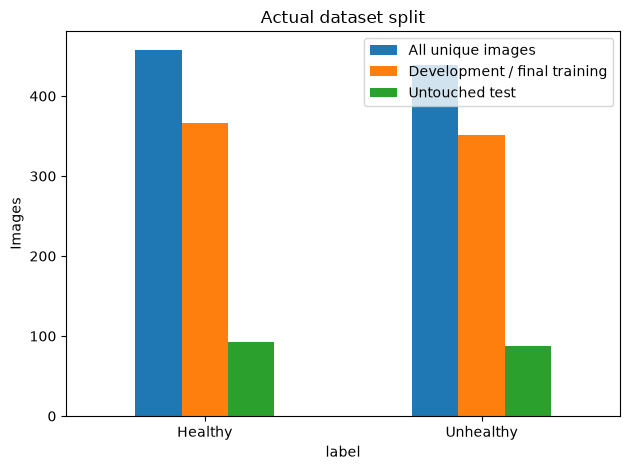

In [6]:
from pathlib import Path

from datetime import datetime, timezone

import json

import time

import hashlib

import joblib

import numpy as np

import pandas as pd

from sklearn.base import clone

from sklearn.dummy import DummyClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score

from sklearn.model_selection import StratifiedGroupKFold

from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

def make_splits(frame):
    y, groups = frame.label.to_numpy(), frame.split_group.to_numpy()
    group_counts = frame.groupby("label").split_group.nunique()
    if group_counts.min() < 5:
        raise ValueError("Need at least five independent groups per class for the 80/20 holdout and grouped CV. Add data or fix grouping; do not weaken leakage protection just to get a score.")
    # Fixed first fold; never search seeds for an easier test set.
    dev, test = next(StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(frame, y, groups))
    cv = list(StratifiedGroupKFold(3, shuffle=True, random_state=SEED).split(dev, y[dev], groups[dev]))
    classes = set(y)
    for a, b in [(dev, test)] + [(dev[a], dev[b]) for a, b in cv]:
        if set(groups[a]) & set(groups[b]):
            raise AssertionError("Data leakage: shared groups across a split.")
        if set(y[a]) != classes or set(y[b]) != classes:
            raise ValueError("A split lacks a class. Collect more independent examples or review the groups.")
        if len(a) < 5:
            raise ValueError("Each training fold needs at least five examples for the nearest-neighbor comparison.")
    return dev, test, cv

if DATA_READY:
    frame, audit = audit_dataset(DATA_DIR, report_dir=OUTPUT_DIR)
    audit["download_coverage"] = coverage
    (OUTPUT_DIR / "data_audit.json").write_text(json.dumps(audit, indent=2), encoding="utf-8")
    dev, test, cv = make_splits(frame)
    display(pd.Series({k: v for k, v in audit.items() if k not in {"rejected_images", "class_counts"}}))
    print("Rejected files:", len(audit["rejected_images"]))
    split_table = pd.DataFrame({
        "All unique images": frame.label.value_counts(),
        "Development / final training": frame.iloc[dev].label.value_counts(),
        "Untouched test": frame.iloc[test].label.value_counts(),
    }).fillna(0).astype(int)
    split_table.loc["TOTAL"] = split_table.sum()
    display(split_table)
    fold_table = pd.DataFrame([{"fold": i+1, "training_images": len(a), "validation_images": len(b)} for i, (a,b) in enumerate(cv)])
    display(fold_table)
    split_table.to_csv(OUTPUT_DIR / "split_counts.csv")
    fold_table.to_csv(OUTPUT_DIR / "cv_fold_counts.csv", index=False)
    split_table.drop(index="TOTAL").plot.bar(title="Actual dataset split", rot=0)
    plt.ylabel("Images"); plt.tight_layout(); plt.show()
else:
    print("Preprocessing is waiting for the complete download.")

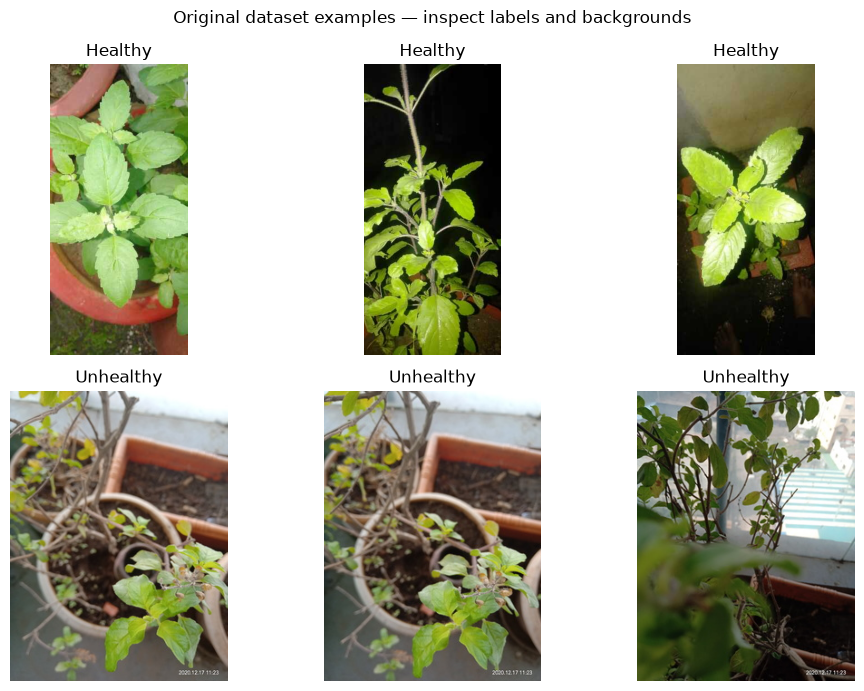

In [7]:
if DATA_READY:
    fig, axes = plt.subplots(2, 3, figsize=(10, 7))
    for row, label in enumerate(sorted(frame.label.unique())):
        samples = frame[frame.label == label].head(3)
        for ax, item in zip(axes[row], samples.itertuples()):
            ax.imshow(read_rgb(DATA_DIR / item.path)); ax.set_title(label); ax.axis("off")
    plt.suptitle("Original dataset examples — inspect labels and backgrounds")
    plt.tight_layout(); plt.show()

## 3. Feature engineering
Classical classifiers require a fixed-length numeric vector. We resize a copy of each image and extract color histograms and color mean/variation in RGB and HSV, local binary patterns (texture), and histogram of oriented gradients (edges). Originals are unchanged. Pixel values are normalized to 0–1. These fixed features use no labels and learn no parameters, so extracting them before cross-validation does not fit on test data.

Whole-image features are fast enough for a laptop but can learn backgrounds, camera conditions, or region rather than leaf quality. Resizing may lose small lesions. A future improvement is validated leaf segmentation and evaluation on new plants and locations.

Optionally set `USE_TRANSFER=True` at the top and install torch/torchvision to compare a frozen pretrained MobileNetV3 feature extractor plus logistic regression. Its ImageNet weights download on first use. The neural network is not fine-tuned; only the downstream classifier is trained. With the default False, no deep model is compared and no deep-learning superiority claim is made.

In [8]:
def handcrafted(image):
    """Whole-frame color + local texture + edge orientation; no learned preprocessing."""
    rgb = np.asarray(image.resize((128, 128), Image.Resampling.BILINEAR), dtype=np.float32) / 255
    hsv = rgb2hsv(rgb)
    parts = []
    for array in (rgb, hsv):
        for channel in range(3):
            h, _ = np.histogram(array[:, :, channel], bins=16, range=(0, 1))
            parts.append(h.astype(np.float32) / h.sum())
        parts.extend([array.mean(axis=(0, 1)), array.std(axis=(0, 1))])
    gray = (rgb2gray(rgb) * 255).astype(np.uint8)
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    h, _ = np.histogram(lbp, bins=np.arange(11), density=False)
    parts.append(h.astype(np.float32) / h.sum())
    small = np.asarray(image.resize((64, 64)).convert("L"), dtype=np.float32) / 255
    parts.append(hog(small, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)))
    return np.concatenate([np.ravel(p) for p in parts]).astype(np.float32)

class MobileNetFeatures:
    """Frozen ImageNet network; only the downstream classifier is fitted on basil."""
    def __init__(self, state_path=None):
        import torch
        from torchvision.models import MobileNet_V3_Small_Weights, mobilenet_v3_small
        torch.set_num_threads(2)
        self.torch = torch
        self.transform = MobileNet_V3_Small_Weights.DEFAULT.transforms()
        self.model = mobilenet_v3_small(weights=None if state_path else MobileNet_V3_Small_Weights.DEFAULT)
        if state_path:
            self.model.load_state_dict(torch.load(state_path, map_location="cpu", weights_only=True))
        self.model.classifier = torch.nn.Identity()
        self.model.eval()

    def __call__(self, images):
        batch = self.torch.stack([self.transform(im) for im in images])
        with self.torch.inference_mode():
            return self.model(batch).numpy().astype(np.float32)

def extract_features(frame, root, transfer=False, batch_size=16):
    """Only fixed features are extracted here; scalers fit inside training folds."""
    bank = {"handcrafted": []}
    encoder = MobileNetFeatures() if transfer else None
    if encoder:
        bank["mobilenet"] = []
    for start in range(0, len(frame), batch_size):
        batch = frame.iloc[start:start + batch_size]
        images = [read_rgb(Path(root) / p) for p in batch.path]
        bank["handcrafted"].extend(handcrafted(im) for im in images)
        if encoder:
            bank["mobilenet"].extend(encoder(images))
        print(f"Features: {min(start + batch_size, len(frame))}/{len(frame)}", flush=True)
    return {key: np.asarray(value, dtype=np.float32) for key, value in bank.items()}

if DATA_READY:
    bank = extract_features(frame, DATA_DIR, transfer=USE_TRANSFER)
    print({name: matrix.shape for name, matrix in bank.items()})
else:
    print("Feature extraction is waiting for images.")

Features: 16/897


Features: 32/897


Features: 48/897


Features: 64/897


Features: 80/897


...

Features: 864/897


Features: 880/897


Features: 896/897


Features: 897/897


{'handcrafted': (897, 1882)}


## 4. Model selection and comparison
Compare a majority baseline, logistic regression (two regularization settings), RBF support vector machine (two settings), random forest, and 5-nearest neighbors. Logistic regression is a simple linear reference; SVM can model nonlinear boundaries; random forest learns nonlinear feature interactions; nearest neighbors uses feature similarity. These are practical CPU candidates for a modest image dataset. Training a large neural network from scratch is not included.

Select the highest **mean validation macro-F1** over three grouped folds, not the highest test accuracy. Macro-F1 gives Healthy and Unhealthy equal weight despite unequal class counts. Report fold variation, validation accuracy, and fit time as context. Exact score ties use lower fit time, then model name; timing is hardware-dependent. Small score differences do not prove that one model is better. The test set remains untouched during selection.

Comparing Majority baseline


Comparing Logistic regression C=0.1


Comparing Logistic regression C=1.0


Comparing RBF SVM C=1.0


Comparing RBF SVM C=10.0


Comparing Random forest


Comparing 5-nearest neighbors


,model,features,cv_macro_f1,cv_std,cv_accuracy,mean_fit_seconds
0,Random forest,handcrafted,0.963648,5.248333e-03,0.963738,0.961041
1,RBF SVM C=10.0,handcrafted,0.953943,1.564970e-02,0.953975,0.264264
2,RBF SVM C=1.0,handcrafted,0.938557,1.687733e-02,0.938633,0.279030
3,Logistic regression C=1.0,handcrafted,0.917710,7.111182e-03,0.917713,0.039403
4,Logistic regression C=0.1,handcrafted,0.914918,5.218036e-03,0.914923,0.135971
5,5-nearest neighbors,handcrafted,0.891194,1.806359e-02,0.891213,0.022130
6,Majority baseline,handcrafted,0.337950,5.551115e-17,0.510460,0.003063


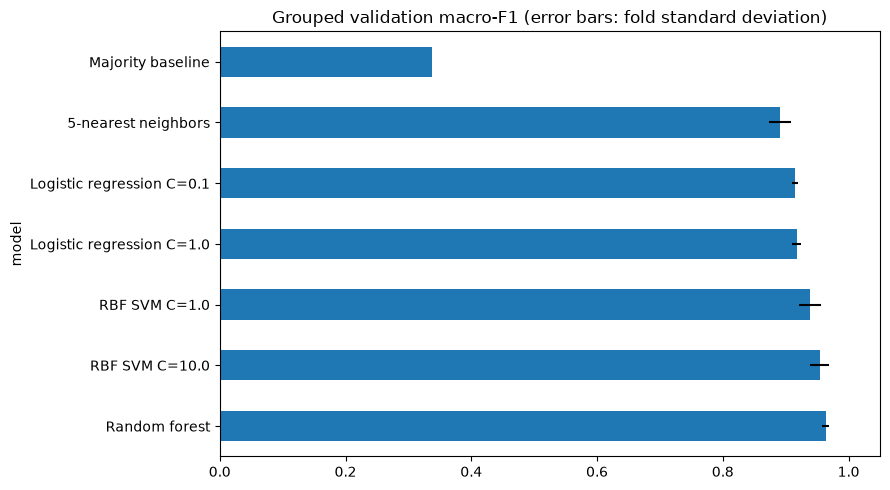

Selected: Random forest; highest mean validation macro-F1 = 0.9636.


In [9]:
def candidates(include_transfer=False):
    options = [("Majority baseline", "handcrafted", DummyClassifier(strategy="most_frequent"))]
    for c in (0.1, 1.0):
        options.append((f"Logistic regression C={c}", "handcrafted", make_pipeline(StandardScaler(), LogisticRegression(C=c, max_iter=3000, class_weight="balanced", random_state=SEED))))
    for c in (1.0, 10.0):
        options.append((f"RBF SVM C={c}", "handcrafted", make_pipeline(StandardScaler(), SVC(C=c, kernel="rbf", class_weight="balanced", random_state=SEED))))
    options.append(("Random forest", "handcrafted", RandomForestClassifier(n_estimators=200, min_samples_leaf=2, max_features="sqrt", class_weight="balanced", random_state=SEED, n_jobs=2)))
    options.append(("5-nearest neighbors", "handcrafted", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))))
    if include_transfer:
        for c in (0.1, 1.0):
            options.append((f"MobileNetV3 + logistic C={c}", "mobilenet", make_pipeline(StandardScaler(), LogisticRegression(C=c, max_iter=3000, class_weight="balanced", random_state=SEED))))
    return options

def compare_models(bank, frame, dev, cv):
    y = frame.label.to_numpy()
    rows, estimators = [], {}
    for name, feature, estimator in candidates("mobilenet" in bank):
        scores, acc, elapsed = [], [], []
        x = bank[feature]
        print(f"Comparing {name}", flush=True)
        for train_rel, val_rel in cv:
            tr, va = dev[train_rel], dev[val_rel]
            fitted = clone(estimator)
            start = time.perf_counter()
            fitted.fit(x[tr], y[tr])
            elapsed.append(time.perf_counter() - start)
            pred = fitted.predict(x[va])
            scores.append(f1_score(y[va], pred, average="macro", zero_division=0))
            acc.append(accuracy_score(y[va], pred))
        rows.append({"model": name, "features": feature, "cv_macro_f1": float(np.mean(scores)),
                     "cv_std": float(np.std(scores)), "cv_accuracy": float(np.mean(acc)),
                     "mean_fit_seconds": float(np.mean(elapsed)), "fold_f1": scores})
        estimators[name] = (feature, estimator)
    comparison = pd.DataFrame(rows).sort_values(["cv_macro_f1", "mean_fit_seconds", "model"], ascending=[False, True, True]).reset_index(drop=True)
    return comparison, estimators

if DATA_READY:
    comparison, estimators = compare_models(bank, frame, dev, cv)
    display(comparison.drop(columns="fold_f1"))
    comparison.set_index("model").cv_macro_f1.plot.barh(xerr=comparison.cv_std.to_numpy(), figsize=(9,5), title="Grouped validation macro-F1 (error bars: fold standard deviation)")
    plt.xlim(0, 1.05); plt.tight_layout(); plt.show()
    winner = comparison.iloc[0]
    print(f"Selected: {winner.model}; highest mean validation macro-F1 = {winner.cv_macro_f1:.4f}.")
else:
    print("Model comparison has not run. No winner can be claimed yet.")

## 5. Model training
Create a fresh copy of the selected classifier and fit it on the entire development pool, including data that served as validation within the cross-validation folds. The test images are excluded. For scaled models, the saved pipeline includes the scaler fitted only on this development pool. A fixed seed improves reproducibility; exact numerical results may still vary across package versions or hardware.

In [10]:
def fit_selected(comparison, estimators, bank, frame, dev):
    chosen = comparison.iloc[0]
    feature, estimator = estimators[chosen.model]
    fitted = clone(estimator).fit(bank[feature][dev], frame.label.to_numpy()[dev])
    return {"estimator": fitted, "feature": feature, "feature_version": FEATURE_VERSION,
            "name": chosen.model, "classes": list(fitted.classes_), "seed": SEED}

if DATA_READY:
    bundle = fit_selected(comparison, estimators, bank, frame, dev)
    print(f"Trained {bundle['name']} on {len(dev)} unique development images.")
else:
    print("No model trained: waiting for the dataset.")

Trained Random forest on 717 unique development images.


## 6. Model evaluation and conclusion
Evaluate the selected trained model once on the held-out test set. Accuracy is the fraction of correct predictions; balanced accuracy averages recall across classes. Precision measures how often a predicted class is correct, recall measures how much of a true class is recovered, and F1 balances precision and recall. The confusion matrix exposes the types of mistakes.

A group bootstrap interval describes macro-F1 uncertainty in this holdout. It is not a guarantee for different farms, phones, or plants. Inspect errors without repeatedly tuning against the same test set. If you use these test findings to redesign the model, collect a new independent test set for the next final assessment.

accuracy                                                                0.955556
balanced_accuracy                                                       0.954545
macro_f1                                                                0.955357
macro_f1_group_bootstrap_95_interval    [0.9220655008138102, 0.9832552925047623]
classifier_ms_per_image                                                 0.385728
test_images                                                                  180
dtype: object

,precision,recall,f1-score,support
Healthy,0.920000,1.000000,0.958333,92.000000
Unhealthy,1.000000,0.909091,0.952381,88.000000
accuracy,0.955556,0.955556,0.955556,0.955556
macro avg,0.960000,0.954545,0.955357,180.000000
weighted avg,0.959111,0.955556,0.955423,180.000000


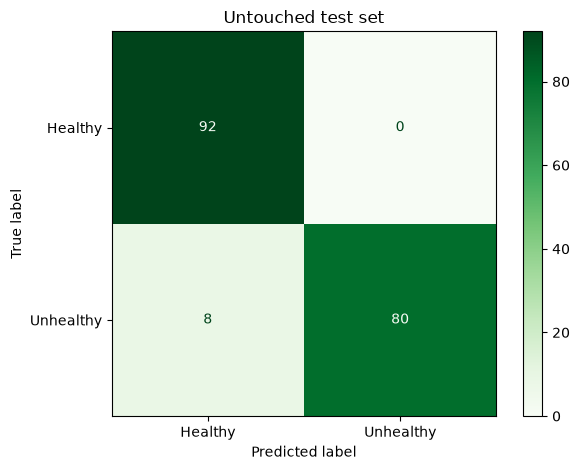

Experiment scope: PARTIAL DATASET
Conclusion: Random forest was selected by grouped validation macro-F1.
Used 897 unique images: 717 final training and 180 test.
Test accuracy: 95.56%; balanced accuracy: 95.45%; macro-F1: 0.9554.
Validation macro-F1 improvement over majority baseline: 0.6257.
Missing data: 233 listed images. No Pune images were available in the supplied ZIP; performance on that region is unknown.
Suitability: a research prototype for similar dataset images. New-plant validation is still required before practical reliance.
Health is confounded with collection conditions: the healthy images span regional folders while unhealthy images have a separate source folder.
This experiment cannot establish that the model learned health rather than background, camera or region. It is not a disease diagnosis or food-safety test.


In [11]:
def evaluate_model(bundle, bank, frame, test):
    y = frame.label.to_numpy()[test]
    start = time.perf_counter()
    pred = bundle["estimator"].predict(bank[bundle["feature"]][test])
    latency = (time.perf_counter() - start) * 1000 / len(test)
    classes = bundle["classes"]
    # Group bootstrap reflects correlated observations; interval is descriptive.
    rng = np.random.default_rng(SEED)
    groups = frame.split_group.to_numpy()[test]
    unique = np.unique(groups)
    boot = []
    for _ in range(500):
        sampled = rng.choice(unique, len(unique), replace=True)
        idx = np.concatenate([np.flatnonzero(groups == group) for group in sampled])
        if set(y[idx]) == set(classes):
            boot.append(f1_score(y[idx], pred[idx], labels=classes, average="macro", zero_division=0))
    return {"accuracy": float(accuracy_score(y, pred)), "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
            "macro_f1": float(f1_score(y, pred, average="macro", zero_division=0)),
            "macro_f1_group_bootstrap_95_interval": np.quantile(boot, [.025, .975]).tolist() if boot else None,
            "classifier_ms_per_image": latency, "test_images": len(test),
            "classification_report": classification_report(y, pred, labels=classes, output_dict=True, zero_division=0),
            "confusion_matrix": confusion_matrix(y, pred, labels=classes).tolist(), "classes": classes}, pred

if DATA_READY:
    metrics, predictions = evaluate_model(bundle, bank, frame, test)
    display(pd.Series({k:v for k,v in metrics.items() if k not in {"classification_report", "confusion_matrix", "classes"}}))
    display(pd.DataFrame(metrics["classification_report"]).T)
    from sklearn.metrics import ConfusionMatrixDisplay
    ConfusionMatrixDisplay(np.array(metrics["confusion_matrix"]), display_labels=bundle["classes"]).plot(cmap="Greens")
    plt.title("Untouched test set"); plt.tight_layout(); plt.show()
    print("Experiment scope:", "PARTIAL DATASET" if IS_PARTIAL_DATASET else "Full listed dataset")
    print(f"Conclusion: {bundle['name']} was selected by grouped validation macro-F1.")
    print(f"Used {len(frame)} unique images: {len(dev)} final training and {len(test)} test.")
    print(f"Test accuracy: {metrics['accuracy']:.2%}; balanced accuracy: {metrics['balanced_accuracy']:.2%}; macro-F1: {metrics['macro_f1']:.4f}.")
    baseline_f1 = float(comparison.loc[comparison.model == "Majority baseline", "cv_macro_f1"].iloc[0])
    print(f"Validation macro-F1 improvement over majority baseline: {comparison.iloc[0].cv_macro_f1 - baseline_f1:.4f}.")
    if IS_PARTIAL_DATASET:
        print("Missing data:", coverage["missing_images"], "listed images. No Pune images were available in the supplied ZIP; performance on that region is unknown.")
    print("Suitability: a research prototype for similar dataset images. New-plant validation is still required before practical reliance.")
    print("Health is confounded with collection conditions: the healthy images span regional folders while unhealthy images have a separate source folder.")
    print("This experiment cannot establish that the model learned health rather than background, camera or region. It is not a disease diagnosis or food-safety test.")
else:
    print("Accuracy, test counts and a measured conclusion will appear after training. They are not available yet.")

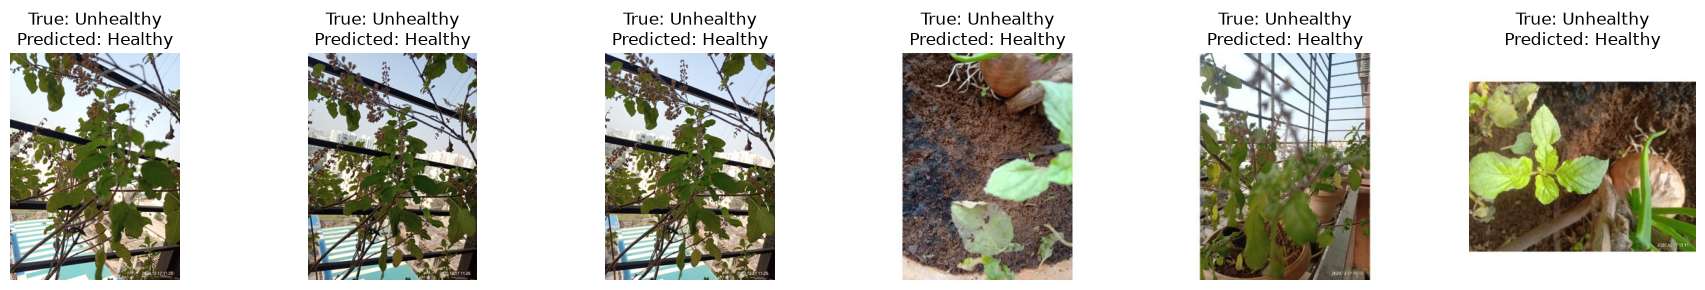

In [12]:
if DATA_READY:
    mistakes = frame.iloc[test].copy()
    mistakes["prediction"] = predictions
    mistakes = mistakes[mistakes.label != mistakes.prediction].head(6)
    if mistakes.empty:
        print("No mistakes in this holdout; this does not imply perfect real-world accuracy.")
    else:
        fig, axes = plt.subplots(1, len(mistakes), figsize=(3*len(mistakes), 3), squeeze=False)
        for ax, item in zip(axes.ravel(), mistakes.itertuples()):
            ax.imshow(read_rgb(DATA_DIR / item.path))
            ax.set_title(f"True: {item.label}\nPredicted: {item.prediction}"); ax.axis("off")
        plt.tight_layout(); plt.show()

## 7. Save and use the trained model in this notebook
Save the fitted classifier, preprocessing pipeline, dataset fingerprint, comparison, split membership, per-image test predictions, and metrics in a single generated `outputs/` folder. This keeps the project clean while preserving reproducible evidence. Optional MobileNet weights are saved if that feature pipeline wins. Package versions are recorded as well.

Reload the saved model and predict a new local image with the exact same feature computation. **Only load model files that you created or trust**: joblib files can execute code when opened. A class label is not a calibrated probability. The model cannot reliably reject unrelated objects or non-basil leaves.

The saved model also powers the local **Basil Lab** website at `http://127.0.0.1:8000`. Launch it using `start_web.bat`. The website uses matching image features and reads the measured report from `outputs/`. Training remains self-contained in this notebook; no cloud service is used. Restart the website after a successful retraining run to load the updated model and report.

In [13]:
def save_run(bundle, comparison, metrics, predictions, frame, dev, test, audit, root, output_dir, report_dir):
    out, reports = Path(output_dir), Path(report_dir)
    out.mkdir(parents=True, exist_ok=True)
    reports.mkdir(parents=True, exist_ok=True)
    # Copy pretrained weights locally so deployment never needs a model download.
    if bundle["feature"] == "mobilenet":
        import torch
        from torchvision.models import MobileNet_V3_Small_Weights, mobilenet_v3_small
        model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        torch.save(model.state_dict(), out / "mobilenet_v3_small.pt")
    fingerprint = hashlib.sha256(frame[["path", "label", "sha256", "split_group"]].to_csv(index=False).encode()).hexdigest()
    bundle["dataset_fingerprint"] = fingerprint
    chosen = comparison.iloc[0]
    reason = (f"{chosen.model} had the highest mean grouped 3-fold development macro-F1 ({chosen.cv_macro_f1:.4f}). "
              "Macro-F1 weights each class equally. Exact score ties are broken by mean classifier fitting time, then model name. "
              "The holdout was excluded from selection. Close CV results are uncertain, not proof of superiority.")
    summary = {"status": "trained", "trained_at": datetime.now(timezone.utc).isoformat(),
               "selected_model": bundle["name"], "features": bundle["feature"], "classes": bundle["classes"],
               "selection_reason": reason, "dataset_fingerprint": fingerprint, "data_audit": audit,
               "development_images": len(dev), "test_images": len(test), "metrics": metrics,
               "comparison": comparison.drop(columns="fold_f1").to_dict("records"),
               "limitations": ["Research prototype; not a disease diagnosis or food-safety test.",
                               "Labels come from the supplied dataset; listed diseases are not assumed to be labelled classes.",
                               "Whole-image features may learn background, lighting or basil variety rather than health.",
                               "No calibrated confidence or reliable non-leaf/out-of-distribution detector is provided.",
                               "No external-site or new-plant validation has been performed.",
                               "Bootstrap interval reflects this grouped holdout, not all sources of uncertainty."],
               "dataset_scope": "partial" if audit.get("download_coverage", {}).get("partial_dataset") else "complete_listed_counts",
               "transfer_compared": "mobilenet" in set(comparison.features)}
    if audit.get("download_coverage", {}).get("partial_dataset"):
        summary["limitations"].append("Partial download: missing images and regions are not represented; results do not describe the complete IEEE dataset.")
    split = frame.copy()
    split["split"] = "development"
    split.loc[test, "split"] = "test"
    split.to_csv(reports / "split_manifest.csv", index=False)
    comparison.to_csv(reports / "model_comparison.csv", index=False)
    test_results = frame.iloc[test][["path", "label", "split_group"]].copy()
    test_results["prediction"] = predictions
    test_results.to_csv(reports / "test_predictions.csv", index=False)
    # Replace artifact only after all calculations succeed. Never load uploaded joblib files.
    joblib.dump(bundle, out / "model.tmp")
    (out / "model.tmp").replace(out / "model.joblib")
    (reports / "results.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    return summary

if DATA_READY:
    summary = save_run(bundle, comparison, metrics, predictions, frame, dev, test, audit, DATA_DIR, OUTPUT_DIR, OUTPUT_DIR)
    import importlib.metadata
    packages = ["numpy", "pandas", "pillow", "scipy", "scikit-learn", "scikit-image", "matplotlib", "joblib"]
    if USE_TRANSFER: packages += ["torch", "torchvision"]
    versions = {package: importlib.metadata.version(package) for package in packages}
    (OUTPUT_DIR / "environment.json").write_text(json.dumps({"python": sys.version, "packages": versions}, indent=2))
    print(summary["selection_reason"])
    print("Saved model and all results to:", OUTPUT_DIR)
else:
    print("No model or training results saved because the dataset is incomplete.")

Random forest had the highest mean grouped 3-fold development macro-F1 (0.9636). Macro-F1 weights each class equally. Exact score ties are broken by mean classifier fitting time, then model name. The holdout was excluded from selection. Close CV results are uncertain, not proof of superiority.
Saved model and all results to: D:\SLIIT\projectr\Dataset_Train\outputs


In [14]:
def predict_image(image_path):
    """Use only the trusted model produced above, with identical image features."""
    model_path = OUTPUT_DIR / "model.joblib"
    if not model_path.exists():
        raise FileNotFoundError("Run training first; no saved model exists.")
    saved = joblib.load(model_path)
    if saved["feature_version"] != FEATURE_VERSION:
        raise ValueError("Feature version mismatch. Use the notebook that trained this model.")
    im = read_rgb(Path(image_path))
    if saved["feature"] == "mobilenet":
        features = MobileNetFeatures(OUTPUT_DIR / "mobilenet_v3_small.pt")([im])
    else:
        features = handcrafted(im)[None, :]
    label = saved["estimator"].predict(features)[0]
    display(im.resize((300, max(16, int(300 * im.height / im.width)))))
    print("Predicted quality:", label)
    print("Model:", saved["name"])
    print("Experimental prediction, not a diagnosis or calibrated confidence score.")
    return str(label)

NEW_IMAGE = ""  # Example: r"C:\Users\herat\Pictures\basil.jpg"
if NEW_IMAGE:
    predicted_label = predict_image(NEW_IMAGE)
else:
    print("After training, set NEW_IMAGE to your photo path and run this cell.")

After training, set NEW_IMAGE to your photo path and run this cell.


### Re-running and interpreting the experiment
Use **Restart Kernel and Run All** to reproduce the experiment on the available data, or after adding more images. Review the inventory, rejected images, duplicate groups, and class counts before trusting the metrics. The notebook reuses no stale result variables after a restart. A later successful training run replaces the generated results in `outputs/`; copy that folder elsewhere first if you need to retain an earlier experiment.

The winner is the best observed candidate under this experiment, not necessarily the best possible model. Report the source DOI, unique-image counts, split counts, grouping limitations, validation comparison, and test metrics together. A strong score on photographs from these collection conditions does not establish performance on new plants.